# Seaborn ile Lineer Regresyon

🚀 Seaborn kullanarak Lineer Regresyon yapmaya başlayalım!

Hedefimiz şunların ilk anlayışını elde etmektir:
- `orders` özellikleri ve
- ilgili `review_scores`

In [ ]:
%load_ext autoreload
%autoreload 2

In [6]:
# Import Modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

⚠️ Devam etmeden önce:
* 💾 Önceki birimin Orders meydan okumasının çözümünü indirin
* 👥 `order_solution.py` dosyasının içeriğini kopyalayıp `olist/order.py` dosyanıza yapıştırın

⚠️ Ayrıca `olist` reponuzda `order.py` dosyasındaki kod değişikliklerini commit etmeyi unutmayın!

👇 Öncelikle `orders` veri setini içe aktarın

In [7]:
# Import your orders training set
from olist.order import Order

orders = Order().get_training_data(with_distance_seller_customer=False)

## 1 - Özelliklerin korelasyonunu inceleyin

❓Özellikler arasındaki çeşitli korelasyonları inceleyin: hangi özellik `review_score` ile en çok ilişkilidir?

<details>
    <summary>▸ İpucu</summary>

* `DataFrame.corr(numeric_only=True)` öğesini `sns.heatmap()` ve `cmap='coolwarm'` ile birlikte kullanın
* `review_score` ile her özellik arasındaki korelasyon katsayılarının mutlak değerlerine bakın
    * katsayı ne kadar yüksekse, verilen özellik `review_score` ile o kadar çok ilişkilidir (pozitif veya negatif olarak)

</details>

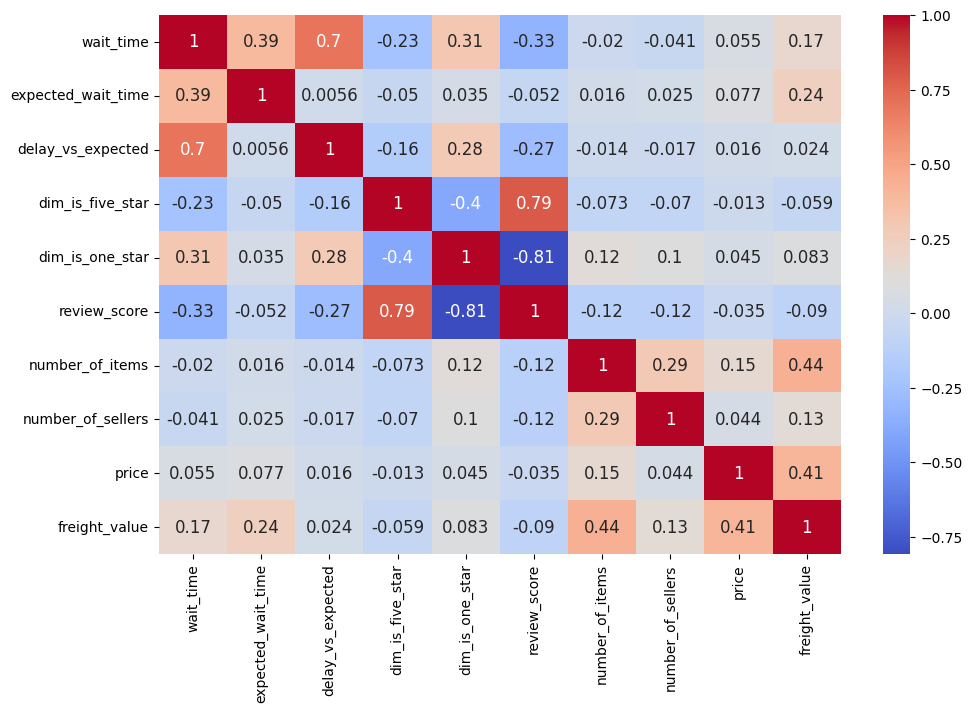

In [8]:
# Correlation plot
plt.figure(figsize=(11,7))
sns.heatmap(
    data=orders.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    annot_kws={"size": 12}
);


In [9]:
round(np.abs(orders.corr(numeric_only=True)['review_score']).sort_values(ascending = False), 2)

review_score          1.00
dim_is_one_star       0.81
dim_is_five_star      0.79
wait_time             0.33
delay_vs_expected     0.27
number_of_items       0.12
number_of_sellers     0.12
freight_value         0.09
expected_wait_time    0.05
price                 0.03
Name: review_score, dtype: float64

* 😏 _Kaptan Gözlemlendi :_
    * `review_score` kendisiyle %100 ilişkilidir
    * ve `dim_is_one_star` ile `dim_is_five_star` ile güçlü bir şekilde ilişkilidir...
* ⚠️ `review_score` ile ilgili sonraki en yüksek iki korelasyon katsayısı:
    * `wait_time` : - 34%
    * `delay_vs_expected` : - 27%

## 2. `review_score` ile teslimat süresinin Lineer Regresyonu

👉 Görünüşe göre `review_score` çoğunlukla `wait_time` (= - 34%) ile `delay_vs_expected` (- 27%) ile ilişkilidir.

🎨 Bu korelasyonları `seaborn` ile araştıralım

### 2.1 Grafikler
❓ `review_score` değerini sırasıyla `wait_time` ve `delay_vs_expected` ile regrese eden 2 grafik oluşturun.

<u>İpuçları</u>:

- Hız açısından veri çerçevenizi rastgele 10.000 satırlık bir örneğe indirin
- `DataFrame.sample()` öğesini sabitlenen bir `random_state` ile kullanın (gerekirse her yürütmede örneği değiştirmekten kaçınmak için)
- `sns.regplot()` öğesini `regression` çizgilerini çizmek için kullanın
- Dağılım grafiği yoğunluğunu daha iyi görselleştirmek için bazı `y_jitter` parametreleri ekleyin
- `sns.regplot()` işleminden hemen sonra bunu ekleyerek aykırı değerleri gizlemek için `xlim` ve `ylim` sınırlarını belirleyin (aynı hücrede):
  ```python
  plt.xlim(right=70)
  plt.ylim(bottom=0)
  ```

In [10]:
sample = orders.sample(10000, random_state=42)

(0.0, 5.974052917256717)

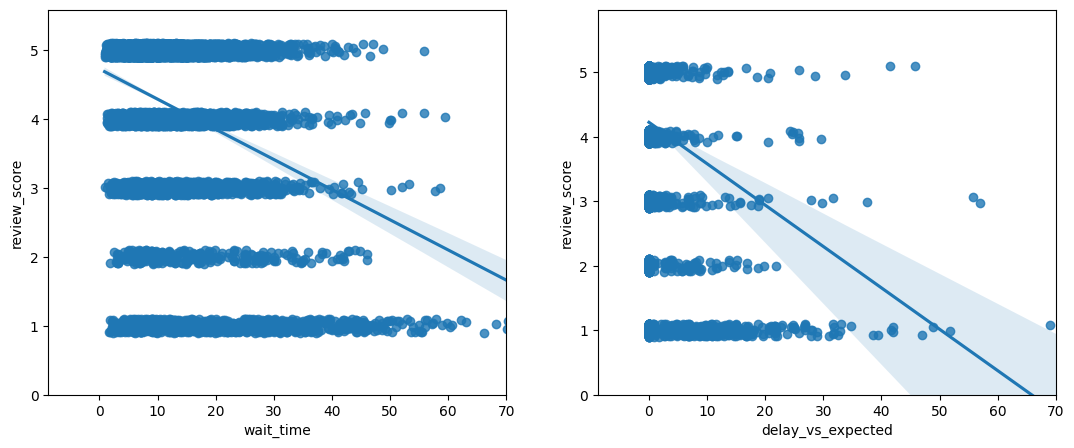

In [11]:
plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
sns.regplot(x=sample.wait_time, y=sample.review_score, y_jitter=.1)
plt.xlim(right=70)
plt.ylim(bottom=0)

plt.subplot(1,2,2)
sns.regplot(x=sample.delay_vs_expected, y=sample.review_score, y_jitter=.1)
plt.xlim(right=70)
plt.ylim(bottom=0)

ℹ️ `regplot` ne yaptı?

👉 `review_score` ile `wait_time` ve `delay_vs_exp` arasında bir `Lineer Regresyon` gerçekleştirmeyi denedi

🧐 Çok yorumlanabilir görünmüyor, değil mi ?

👉 Haklısınız: beş farklı inceleme puanımız vardır, bu da beş farklı olası değere (örneğin: "çok kötü", "kötü", "ortalama", "iyi" ve "çok iyi") sahip kategorik bir değişken olarak yorumlanabilir ve biz bunu `wait_time` ve `delay_vs_exp` olmak üzere iki sürekli değere karşı regrese etmeye çalışıyoruz.

👀 Ancak, regresyon çizgilerine bakarak çok sezgisel bir örüntü görebiliriz: bekleme süresi ve/veya gecikme ne kadar uzunsa, inceleme puanı o kadar düşüktür - şaşırtıcı değil. Ama inceleme puanı ne kadar hızlı düşüyor?

### 2.2 Yorumlama

❓Her bir eğrinin `eğimini` görsel olarak hesaplamaya çalışın.

✍️ Veri olmayan bir kitleye açıklamak isteseydiniz bu katsayıları düz Türkçe ile nasıl yorumlardığınızı yazın.

<details>
    <summary>Cevap</summary>

- `Eğim wait_time ≈ -0.05` : "Bir siparişin teslimat için beklemesi gereken her ek gün için, inceleme puanı ortalama olarak 0,05 azalır"
- `Eğim delay ≈ -0.1` : "Bir siparişin tahmini teslimat tarihinden _sonra_ teslimat edilmesi için beklemesi gereken her ek gün için, inceleme puanı ortalama olarak 0,1 azalır"

❓ Gecikmenin bekleme süresinden daha etkili görünmesine şaşırdınız mı?

👉 Siparişinizi almayı beklemede sabırsız olabilirsiniz ve kısa bekleme süresi istersiniz, ancak paketinizi beklenen teslimat tarihinden sonra almaktan daha da hayal kırıklığına uğrarsınız!

</details>

### 2.3 İstatistiksel Analiz

Bu regplot'lar için 100.000 siparişin tümünü kullansaydık da, bu siparişler sonuçta yalnızca 16 aylık verileri temsil ediyor...

⚠️⚠️⚠️ Bu katsayılar **istatistiksel olarak anlamlı** olduğundan **ne kadar emin** olabiliriz? ⚠️⚠️⚠️

⚡️ Bu katsayıların istatistiksel anlamlılığı hakkında sorular:

* Bu katsayılar gelecekteki siparişlere iyi bir şekilde genelleştirilebilir mi (diğer her şey eşit kaldığında)? (*İdeal cevap: Evet*)
* Bu katsayıların sınırlı gözlem dönemindeki rastgele dalgalanmaları yakalamaması konusunda emin miyiz? (*İdeal cevap: Hayır*)

🧐 Bu iki eğim için ortalama değer etrafında **`güven aralığını`** tahmin etmemiz gerekir:
$$eğim_{wait} = -0.05 ± \ ?? \ \text{[95\% aralık]} $$
$$eğim_{delay} = -0.1 ± \ ?? \ \text{[95\% aralık]} $$

⭐️ Neyse ki, `Seaborn` zaten bu 95% güven aralığını regresyon çizgisi etrafında gölgeli mavi bir koni ile hesaplıyor!

❓İki güven aralığını görselleştirmek için `Seaborn` `regplot` öğesini tekrar kullanın:
- **Örnek veri kümesinin boyutunu** değiştirin:
    - Örnek boyutu küçüldükçe eğimin nasıl değiştiğine dikkat edin.
    - Güven aralığı ne olacak?
- `regplot` parametresi olan `ci` öğesini (varsayılan olarak %95) oynatarak **güven aralığının boyutunu** değiştirin

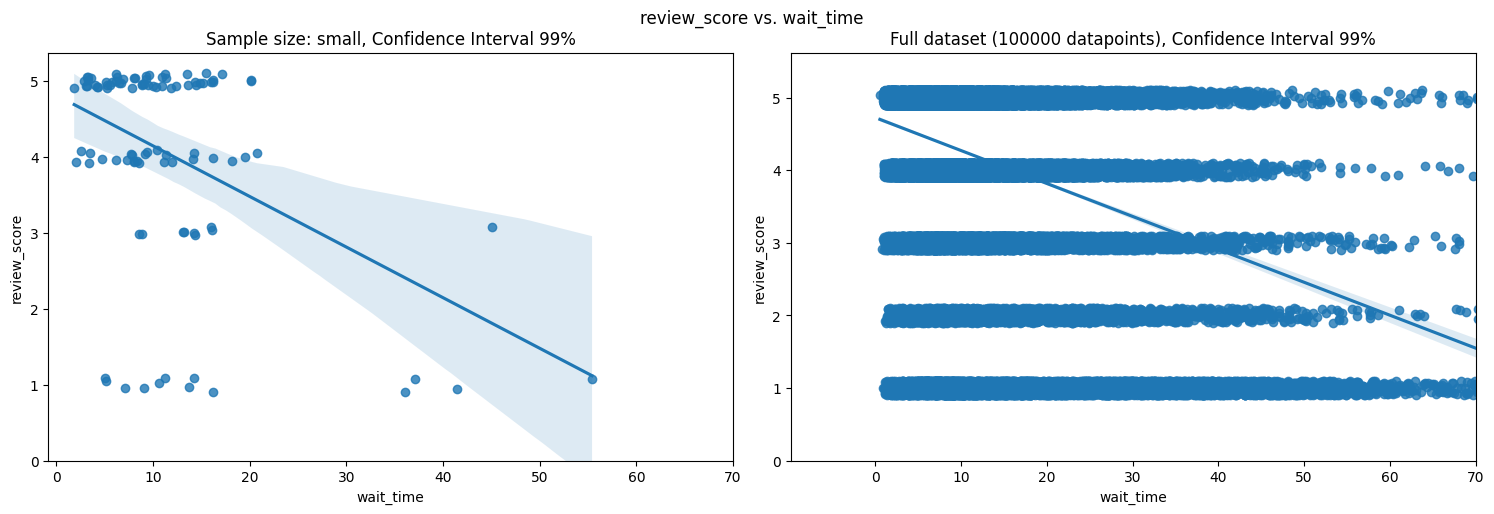

In [12]:
sample = orders.sample(100, random_state=42)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

fig.suptitle('review_score vs. wait_time')
fig.tight_layout()

sns.regplot(x=sample.wait_time, y=sample.review_score, y_jitter=.1, ci=99, ax=axes[0])
axes[0].set_xlim(right=70)
axes[0].set_ylim(bottom=0)
axes[0].set_title("Sample size: small, Confidence Interval 99%")


sns.regplot(x=orders.wait_time, y=orders.review_score, y_jitter=.1, ci=99, ax=axes[1])
axes[1].set_xlim(right=70)
axes[1].set_ylim(bottom=0)
axes[1].set_title("Full dataset (100000 datapoints), Confidence Interval 99%")

plt.show();

🔎 Yorumlama:

* **Boş Hipotez** $H_0$ : "bu değişken inceleme puanını etkilemez", yani katsayısı sıfıra eşittir

Tüm veri noktalarımızı çizerken:
- Eğim için %95 güven aralığı 0 değerini içermez.
    - 👉 `Daha yavaş teslimatların daha zayıf incelemeler ile ilişkili olması konusunda %95 güvemiz vardır`.
- "Teslimat süresinin inceleme puanlarına olan etkisi neredeyse sıfırdır" boş hipotezi ile ilişkili **`p-değeri`** %5'ten düşüktür
    - 👉 Bu boş hipotezi güvenle reddedebilir ve **`alternatif hipotez`** = `"teslimat süresinin inceleme puanı üzerinde bir etkisi vardır"` göz önünde bulundurabilir

🔥 Bulgularımız **istatistiksel olarak anlamlı** olduğu söyleniyor.

⚠️ Ancak, **korelasyon nedensellik anlamına gelmez**.

- Belirli ürünleri teslimat etmek doğal olarak daha yavaş olabilir (örneğin ağır ürünler)
    - Bu ürün kategorileri, teslimat sürelerine bakılmaksızın sıklıkla düşük review_score'a sahip olacaktır.

👉 **Karıştırıcı faktörleri** belirlemek çok önemlidir ve basit tek değişkenli regresyon ile yapılamaz.

</details>

---
🏁 Tebrikler!

🙏 Notebook'unuzu `commit` ve `push` etmeyi unutmayın